In [2]:
!pip install sentence-transformers numpy pandas matplotlib scikit-learn -q

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')
print("Библиотеки загружены")

/home/flame/PycharmProjects/praktika_bwt2506/my_jupyter_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Библиотеки загружены


In [3]:
with open('code_corpus.json', 'r', encoding='utf-8') as f:
    code_corpus = json.load(f)
with open('eval_questions.json', 'r', encoding='utf-8') as f:
    eval_questions = json.load(f)
with open('categories.json', 'r', encoding='utf-8') as f:
    categories_data = json.load(f)

print(f"Загружено {len(code_corpus)} фрагментов кода")
print(f"Загружено {len(eval_questions)} вопросов")
print(f"Загружено {len(categories_data['categories'])} категорий")

Загружено 200 фрагментов кода
Загружено 25 вопросов
Загружено 5 категорий


In [4]:
corpus_texts = [f"{item['code']} {item['description']}" for item in code_corpus]
queries = [q['query'] for q in eval_questions]
correct_ids = [q['correct_chunk_id'] for q in eval_questions]

print("Данные подготовлены")
print(f"Пример: {corpus_texts[0][:100]}...")

Данные подготовлены
Пример: def verify_jwt_token(token: str, secret: str) -> dict:
    """Проверяет JWT-токен и возвращает paylo...


In [6]:
model_names = [
    "paraphrase-multilingual-MiniLM-L12-v2",
    "paraphrase-multilingual-mpnet-base-v2"
]

models = {}
for name in model_names:
    print(f"Загружаем {name}...")
    models[name] = SentenceTransformer(name)
    print(f"{name} загружена")

Загружаем paraphrase-multilingual-MiniLM-L12-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9051.60it/s]


paraphrase-multilingual-MiniLM-L12-v2 загружена
Загружаем paraphrase-multilingual-mpnet-base-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10366.08it/s]


paraphrase-multilingual-mpnet-base-v2 загружена


In [7]:
embeddings = {}
for name, model in models.items():
    print(f"[{name}] Генерация...")
    embeddings[name] = model.encode(corpus_texts, show_progress_bar=True, batch_size=32)
    print(f"[{name}] Готово: {embeddings[name].shape}")

[paraphrase-multilingual-MiniLM-L12-v2] Генерация...


Batches: 100%|██████████| 7/7 [00:00<00:00, 18.20it/s]


[paraphrase-multilingual-MiniLM-L12-v2] Готово: (200, 384)
[paraphrase-multilingual-mpnet-base-v2] Генерация...


Batches: 100%|██████████| 7/7 [00:00<00:00, 11.16it/s]

[paraphrase-multilingual-mpnet-base-v2] Готово: (200, 768)


In [11]:
def search(query, model, corpus_emb, top_k=3):
    q_emb = model.encode([query])
    sim = cosine_similarity(q_emb, corpus_emb)[0]
    idx = np.argsort(sim)[::-1][:top_k]
    return idx, sim[idx]

In [13]:
# ID всех фрагментов кода (нужно для поиска)
corpus_ids = [item['id'] for item in code_corpus]
corpus_categories = [item['category'] for item in code_corpus]
query_languages = [q['language'] for q in eval_questions]

print(f"[OK] corpus_ids создан: {len(corpus_ids)} шт")
print(f"[OK] категории: {len(set(corpus_categories))} уникальных")

[OK] corpus_ids создан: 200 шт
[OK] категории: 5 уникальных


In [14]:
results = {}
for name, model in models.items():
    print(f"\n[{name}] тест")
    results[name] = []

    for i, q in enumerate(queries):
        idx, scores = search(q, model, embeddings[name])
        found = [corpus_ids[j] for j in idx]

        results[name].append({
            'query': q,
            'correct': correct_ids[i],
            'found': found,
            'scores': [round(s, 3) for s in scores],
            'ok': correct_ids[i] in found
        })

    ok = sum(1 for r in results[name] if r['ok'])
    print(f"[{name}] Precision@3 = {ok/len(queries):.2%} ({ok}/{len(queries)})")


[paraphrase-multilingual-MiniLM-L12-v2] Тестирую...
[paraphrase-multilingual-MiniLM-L12-v2] Precision@3 = 72.00% (18/25)

[paraphrase-multilingual-mpnet-base-v2] Тестирую...
[paraphrase-multilingual-mpnet-base-v2] Precision@3 = 84.00% (21/25)


In [15]:
print("СРАВНЕНИЕ МОДЕЛЕЙ")

data = []
for name, res in results.items():
    ok = sum(1 for r in res if r['ok'])
    short_name = name.replace('paraphrase-multilingual-', '').replace('-v2', '')
    data.append({
        'Модель': short_name,
        'Precision@3': f"{ok/len(queries):.2%}",
        'Успешно': f"{ok}/{len(queries)}"
    })

df = pd.DataFrame(data)
print(df.to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ
    Модель Precision@3 Успешно
MiniLM-L12      72.00%   18/25
mpnet-base      84.00%   21/25


[INFO] Запускаю t-SNE...
[OK] t-SNE готов: (200, 2)


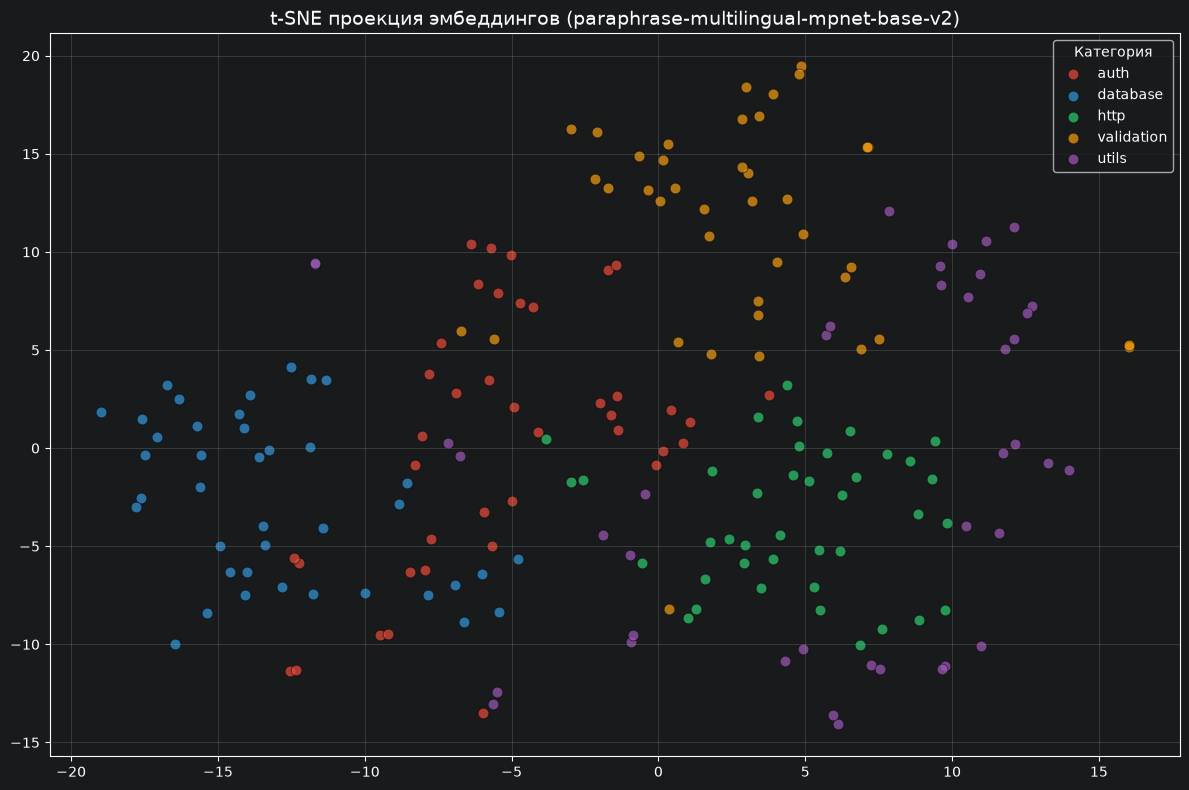

In [16]:
# Берем эмбеддинги лучшей модели (mpnet-base)
best_model_name = "paraphrase-multilingual-mpnet-base-v2"
best_embeddings = embeddings[best_model_name]

# Создаем карту цветов для категорий
category_colors = {
    'auth': '#E74C3C',
    'database': '#3498DB',
    'http': '#2ECC71',
    'validation': '#F39C12',
    'utils': '#9B59B6'
}

# t-SNE проекция на 2D
print("[INFO] Запускаю t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(best_embeddings)
print(f"[OK] t-SNE готов: {coords.shape}")

# Рисуем график
fig, ax = plt.subplots(figsize=(12, 8))

for category, color in category_colors.items():
    mask = [c == category for c in corpus_categories]
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=color,
        label=category,
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidth=0.5
    )

ax.set_title(f"t-SNE проекция эмбеддингов ({best_model_name})", fontsize=14)
ax.legend(title="Категория", loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()